# AgriMind Phase 6: Expert System Chemical Safety Checker

## Proposal objective covered

**Objective 4:** Develop an Expert System / rule-checker to ensure that the AI system does not suggest unsafe or harmful chemical/fertilizer combinations.

## AI type used

This phase uses **Symbolic AI / Rule-Based AI**.

Unlike CNN, ANN, RNN, LSTM, GRU, or RL models, an Expert System does not learn from a training dataset.  
Instead, it uses a human-defined rule base and an inference engine.

## Main purpose

The Expert System acts as a **safety validation layer** after the other AI models.

Example:

```text
ANN recommends fertilizer
RL recommends application action
Expert System checks safety
Final output is SAFE / WARNING / UNSAFE / CRITICAL
```

## Guideline requirements covered

- Source of knowledge / rule base
- Rule base characteristics
- Test case dataset
- Data preprocessing
  - importing libraries
  - creating/loading rule base
  - creating/loading test cases
  - handling missing values
  - duplicate records
  - categorical handling
  - numeric pH handling
  - feature scaling note for pH
- Feature selection approach
- Expert System methodology
- Inference engine
- Evaluation metrics
- Confusion matrix
- Graphs and visualizations
- Rule coverage
- Example safety outputs
- Saved reports, results, rule base, and screenshots

In [1]:
# ============================================================
# Block 1: Import libraries and set environment
# ============================================================

import os
import sys
import json
import subprocess
import warnings

warnings.filterwarnings("ignore")

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn"
}

for import_name, package_name in required_packages.items():
    try:
        __import__(import_name)
    except ModuleNotFoundError:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# Block 2: Define exact project paths
# ============================================================

PROJECT_DIR = r"E:\AI Project\AgriMind_Project"

MODEL_DIR = r"E:\AI Project\AgriMind_Project\models\phase6_expert_system_chemical_safety"
RESULTS_DIR = r"E:\AI Project\AgriMind_Project\results\phase6_expert_system_chemical_safety"
SCREENSHOTS_DIR = r"E:\AI Project\AgriMind_Project\screenshots\phase6_expert_system_chemical_safety"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(SCREENSHOTS_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Project directory exists:", os.path.exists(PROJECT_DIR))
print("Model folder:", MODEL_DIR)
print("Results folder:", RESULTS_DIR)
print("Screenshots folder:", SCREENSHOTS_DIR)

Project directory: E:\AI Project\AgriMind_Project
Project directory exists: True
Model folder: E:\AI Project\AgriMind_Project\models\phase6_expert_system_chemical_safety
Results folder: E:\AI Project\AgriMind_Project\results\phase6_expert_system_chemical_safety
Screenshots folder: E:\AI Project\AgriMind_Project\screenshots\phase6_expert_system_chemical_safety


In [3]:
# ============================================================
# Block 3: Create Expert System rule base
# ============================================================

# Rule base source:
# This prototype uses agricultural safety knowledge encoded as expert-defined rules.
# These rules represent common fertilizer/chemical safety concepts:
# - do not mix certain chemicals directly
# - avoid over-application
# - consider soil pH
# - consider crop growth stage
# - recommend safer alternatives

rule_base = [
    {
        "rule_id": "R001",
        "rule_type": "chemical_incompatibility",
        "chemical_1": "urea",
        "chemical_2": "lime",
        "condition": "apply_together",
        "status": "UNSAFE",
        "severity": "HIGH",
        "reason": "Urea and lime should not be mixed or applied together because ammonia volatilization can increase nitrogen loss.",
        "recommendation": "Apply urea and lime separately with a safe time gap."
    },
    {
        "rule_id": "R002",
        "rule_type": "chemical_incompatibility",
        "chemical_1": "ammonium sulphate",
        "chemical_2": "lime",
        "condition": "apply_together",
        "status": "UNSAFE",
        "severity": "HIGH",
        "reason": "Ammonium fertilizers mixed with lime can increase ammonia loss and reduce fertilizer efficiency.",
        "recommendation": "Do not mix directly. Apply separately with time gap."
    },
    {
        "rule_id": "R003",
        "rule_type": "chemical_incompatibility",
        "chemical_1": "dap",
        "chemical_2": "lime",
        "condition": "apply_together",
        "status": "WARNING",
        "severity": "MEDIUM",
        "reason": "Phosphate fertilizers with lime may reduce phosphorus availability in some soil conditions.",
        "recommendation": "Avoid direct mixing. Apply according to soil test and expert advice."
    },
    {
        "rule_id": "R004",
        "rule_type": "chemical_incompatibility",
        "chemical_1": "single super phosphate",
        "chemical_2": "lime",
        "condition": "apply_together",
        "status": "WARNING",
        "severity": "MEDIUM",
        "reason": "Direct combination may reduce nutrient availability depending on soil condition.",
        "recommendation": "Apply separately and monitor soil pH."
    },
    {
        "rule_id": "R005",
        "rule_type": "over_application",
        "chemical_1": "urea",
        "chemical_2": "",
        "condition": "high_amount",
        "status": "WARNING",
        "severity": "MEDIUM",
        "reason": "High urea application can cause nitrogen loss, leaf burn, or excessive vegetative growth.",
        "recommendation": "Use recommended dose and split application if needed."
    },
    {
        "rule_id": "R006",
        "rule_type": "over_application",
        "chemical_1": "mop",
        "chemical_2": "",
        "condition": "high_amount",
        "status": "WARNING",
        "severity": "MEDIUM",
        "reason": "Excessive potassium fertilizer can disturb nutrient balance.",
        "recommendation": "Use according to soil potassium level."
    },
    {
        "rule_id": "R007",
        "rule_type": "soil_ph_rule",
        "chemical_1": "lime",
        "chemical_2": "",
        "condition": "high_ph",
        "status": "UNSAFE",
        "severity": "HIGH",
        "reason": "Applying lime to already alkaline soil can further increase soil pH and reduce nutrient availability.",
        "recommendation": "Do not apply lime when soil pH is high."
    },
    {
        "rule_id": "R008",
        "rule_type": "soil_ph_rule",
        "chemical_1": "ammonium sulphate",
        "chemical_2": "",
        "condition": "low_ph",
        "status": "WARNING",
        "severity": "MEDIUM",
        "reason": "Ammonium sulphate can acidify soil further when soil pH is already low.",
        "recommendation": "Use carefully and monitor soil pH."
    },
    {
        "rule_id": "R009",
        "rule_type": "growth_stage_rule",
        "chemical_1": "urea",
        "chemical_2": "",
        "condition": "late_stage_high_amount",
        "status": "WARNING",
        "severity": "MEDIUM",
        "reason": "High nitrogen application at late growth stage may be wasteful and can affect crop quality.",
        "recommendation": "Avoid high nitrogen application at late stage unless expert confirms need."
    },
    {
        "rule_id": "R010",
        "rule_type": "growth_stage_rule",
        "chemical_1": "20:20:20 npk",
        "chemical_2": "",
        "condition": "normal_amount",
        "status": "SAFE",
        "severity": "LOW",
        "reason": "Balanced NPK application at recommended amount is generally acceptable when nutrient need exists.",
        "recommendation": "Apply according to recommended dose and crop requirement."
    },
    {
        "rule_id": "R011",
        "rule_type": "chemical_incompatibility",
        "chemical_1": "copper fungicide",
        "chemical_2": "strong acid",
        "condition": "apply_together",
        "status": "CRITICAL",
        "severity": "CRITICAL",
        "reason": "Mixing copper-based products with strong acidic materials can increase phytotoxicity risk.",
        "recommendation": "Do not mix. Consult an agricultural expert."
    },
    {
        "rule_id": "R012",
        "rule_type": "general_safety",
        "chemical_1": "unknown",
        "chemical_2": "",
        "condition": "unknown_chemical",
        "status": "WARNING",
        "severity": "MEDIUM",
        "reason": "Unknown chemicals cannot be verified by the safety rule base.",
        "recommendation": "Do not apply unknown chemical combinations without expert verification."
    }
]

rule_base_df = pd.DataFrame(rule_base)

display(rule_base_df)

print("Number of rules:", len(rule_base_df))

,rule_id,rule_type,chemical_1,chemical_2,condition,status,severity,reason,recommendation
0,R001,chemical_incompatibility,urea,lime,apply_together,UNSAFE,HIGH,Urea and lime should not be mixed or applied t...,Apply urea and lime separately with a safe tim...
1,R002,chemical_incompatibility,ammonium sulphate,lime,apply_together,UNSAFE,HIGH,Ammonium fertilizers mixed with lime can incre...,Do not mix directly. Apply separately with tim...
2,R003,chemical_incompatibility,dap,lime,apply_together,WARNING,MEDIUM,Phosphate fertilizers with lime may reduce pho...,Avoid direct mixing. Apply according to soil t...
3,R004,chemical_incompatibility,single super phosphate,lime,apply_together,WARNING,MEDIUM,Direct combination may reduce nutrient availab...,Apply separately and monitor soil pH.
4,R005,over_application,urea,,high_amount,WARNING,MEDIUM,"High urea application can cause nitrogen loss,...",Use recommended dose and split application if ...
5,R006,over_application,mop,,high_amount,WARNING,MEDIUM,Excessive potassium fertilizer can disturb nut...,Use according to soil potassium level.
6,R007,soil_ph_rule,lime,,high_ph,UNSAFE,HIGH,Applying lime to already alkaline soil can fur...,Do not apply lime when soil pH is high.
7,R008,soil_ph_rule,ammonium sulphate,,low_ph,WARNING,MEDIUM,Ammonium sulphate can acidify soil further whe...,Use carefully and monitor soil pH.
8,R009,growth_stage_rule,urea,,late_stage_high_amount,WARNING,MEDIUM,High nitrogen application at late growth stage...,Avoid high nitrogen application at late stage ...
9,R010,growth_stage_rule,20:20:20 npk,,normal_amount,SAFE,LOW,Balanced NPK application at recommended amount...,Apply according to recommended dose and crop r...


Number of rules: 12


In [4]:
# ============================================================
# Block 4: Rule base characteristics
# ============================================================

rule_base_characteristics = {
    "knowledge_source": "Expert-defined agricultural chemical/fertilizer safety rules for prototype Expert System.",
    "number_of_rules": int(rule_base_df.shape[0]),
    "rule_types": rule_base_df["rule_type"].value_counts().to_dict(),
    "statuses": rule_base_df["status"].value_counts().to_dict(),
    "severity_levels": rule_base_df["severity"].value_counts().to_dict()
}

print(json.dumps(rule_base_characteristics, indent=4))

{
    "knowledge_source": "Expert-defined agricultural chemical/fertilizer safety rules for prototype Expert System.",
    "number_of_rules": 12,
    "rule_types": {
        "chemical_incompatibility": 5,
        "over_application": 2,
        "soil_ph_rule": 2,
        "growth_stage_rule": 2,
        "general_safety": 1
    },
    "statuses": {
        "WARNING": 7,
        "UNSAFE": 3,
        "SAFE": 1,
        "CRITICAL": 1
    },
    "severity_levels": {
        "MEDIUM": 7,
        "HIGH": 3,
        "LOW": 1,
        "CRITICAL": 1
    }
}


In [5]:
# ============================================================
# Block 5: Create test case dataset for Expert System evaluation
# ============================================================

# This is not a training dataset.
# It is a testing/evaluation dataset used to verify whether the rule-based AI returns correct safety decisions.

test_cases = [
    {
        "test_case_id": "TC001",
        "crop": "Tomato",
        "chemical_1": "Urea",
        "chemical_2": "Lime",
        "application_action": "apply_together",
        "amount_level": "normal",
        "soil_ph": 7.2,
        "growth_stage": "middle",
        "expected_status": "UNSAFE"
    },
    {
        "test_case_id": "TC002",
        "crop": "Tomato",
        "chemical_1": "Ammonium Sulphate",
        "chemical_2": "Lime",
        "application_action": "apply_together",
        "amount_level": "normal",
        "soil_ph": 6.8,
        "growth_stage": "middle",
        "expected_status": "UNSAFE"
    },
    {
        "test_case_id": "TC003",
        "crop": "Chilli",
        "chemical_1": "DAP",
        "chemical_2": "Lime",
        "application_action": "apply_together",
        "amount_level": "normal",
        "soil_ph": 7.0,
        "growth_stage": "early",
        "expected_status": "WARNING"
    },
    {
        "test_case_id": "TC004",
        "crop": "Onion",
        "chemical_1": "Single Super Phosphate",
        "chemical_2": "Lime",
        "application_action": "apply_together",
        "amount_level": "normal",
        "soil_ph": 6.7,
        "growth_stage": "early",
        "expected_status": "WARNING"
    },
    {
        "test_case_id": "TC005",
        "crop": "Tomato",
        "chemical_1": "Urea",
        "chemical_2": "",
        "application_action": "apply_single",
        "amount_level": "high",
        "soil_ph": 6.5,
        "growth_stage": "middle",
        "expected_status": "WARNING"
    },
    {
        "test_case_id": "TC006",
        "crop": "Brinjal",
        "chemical_1": "MOP",
        "chemical_2": "",
        "application_action": "apply_single",
        "amount_level": "high",
        "soil_ph": 6.4,
        "growth_stage": "middle",
        "expected_status": "WARNING"
    },
    {
        "test_case_id": "TC007",
        "crop": "Tomato",
        "chemical_1": "Lime",
        "chemical_2": "",
        "application_action": "apply_single",
        "amount_level": "normal",
        "soil_ph": 8.2,
        "growth_stage": "early",
        "expected_status": "UNSAFE"
    },
    {
        "test_case_id": "TC008",
        "crop": "Cabbage",
        "chemical_1": "Ammonium Sulphate",
        "chemical_2": "",
        "application_action": "apply_single",
        "amount_level": "normal",
        "soil_ph": 5.4,
        "growth_stage": "middle",
        "expected_status": "WARNING"
    },
    {
        "test_case_id": "TC009",
        "crop": "Tomato",
        "chemical_1": "Urea",
        "chemical_2": "",
        "application_action": "apply_single",
        "amount_level": "high",
        "soil_ph": 6.3,
        "growth_stage": "late",
        "expected_status": "WARNING"
    },
    {
        "test_case_id": "TC010",
        "crop": "Tomato",
        "chemical_1": "20:20:20 NPK",
        "chemical_2": "",
        "application_action": "apply_single",
        "amount_level": "normal",
        "soil_ph": 6.5,
        "growth_stage": "middle",
        "expected_status": "SAFE"
    },
    {
        "test_case_id": "TC011",
        "crop": "Tomato",
        "chemical_1": "Copper Fungicide",
        "chemical_2": "Strong Acid",
        "application_action": "apply_together",
        "amount_level": "normal",
        "soil_ph": 5.8,
        "growth_stage": "middle",
        "expected_status": "CRITICAL"
    },
    {
        "test_case_id": "TC012",
        "crop": "Tomato",
        "chemical_1": "Unknown Chemical",
        "chemical_2": "",
        "application_action": "apply_single",
        "amount_level": "normal",
        "soil_ph": 6.5,
        "growth_stage": "middle",
        "expected_status": "WARNING"
    },
    {
        "test_case_id": "TC013",
        "crop": "Tomato",
        "chemical_1": "19:19:19 NPK",
        "chemical_2": "",
        "application_action": "apply_single",
        "amount_level": "normal",
        "soil_ph": 6.4,
        "growth_stage": "middle",
        "expected_status": "SAFE"
    },
    {
        "test_case_id": "TC014",
        "crop": "Maize",
        "chemical_1": "50:26:26 NPK",
        "chemical_2": "",
        "application_action": "apply_single",
        "amount_level": "normal",
        "soil_ph": 6.8,
        "growth_stage": "early",
        "expected_status": "SAFE"
    },
    {
        "test_case_id": "TC015",
        "crop": "Tomato",
        "chemical_1": "Magnesium Sulphate",
        "chemical_2": "",
        "application_action": "apply_single",
        "amount_level": "normal",
        "soil_ph": 6.5,
        "growth_stage": "middle",
        "expected_status": "SAFE"
    },
    {
        "test_case_id": "TC016",
        "crop": "Tomato",
        "chemical_1": "Lime",
        "chemical_2": "",
        "application_action": "apply_single",
        "amount_level": "normal",
        "soil_ph": 5.2,
        "growth_stage": "early",
        "expected_status": "SAFE"
    },
    {
        "test_case_id": "TC017",
        "crop": "Tomato",
        "chemical_1": "Urea",
        "chemical_2": "Lime",
        "application_action": "apply_separately",
        "amount_level": "normal",
        "soil_ph": 6.5,
        "growth_stage": "middle",
        "expected_status": "SAFE"
    },
    {
        "test_case_id": "TC018",
        "crop": "Tomato",
        "chemical_1": "DAP",
        "chemical_2": "",
        "application_action": "apply_single",
        "amount_level": "normal",
        "soil_ph": 6.5,
        "growth_stage": "middle",
        "expected_status": "SAFE"
    }
]

test_cases_df = pd.DataFrame(test_cases)

display(test_cases_df)

print("Number of test cases:", len(test_cases_df))

,test_case_id,crop,chemical_1,chemical_2,application_action,amount_level,soil_ph,growth_stage,expected_status
0,TC001,Tomato,Urea,Lime,apply_together,normal,7.2,middle,UNSAFE
1,TC002,Tomato,Ammonium Sulphate,Lime,apply_together,normal,6.8,middle,UNSAFE
2,TC003,Chilli,DAP,Lime,apply_together,normal,7.0,early,WARNING
3,TC004,Onion,Single Super Phosphate,Lime,apply_together,normal,6.7,early,WARNING
4,TC005,Tomato,Urea,,apply_single,high,6.5,middle,WARNING
5,TC006,Brinjal,MOP,,apply_single,high,6.4,middle,WARNING
6,TC007,Tomato,Lime,,apply_single,normal,8.2,early,UNSAFE
7,TC008,Cabbage,Ammonium Sulphate,,apply_single,normal,5.4,middle,WARNING
8,TC009,Tomato,Urea,,apply_single,high,6.3,late,WARNING
9,TC010,Tomato,20:20:20 NPK,,apply_single,normal,6.5,middle,SAFE


Number of test cases: 18


In [6]:
# ============================================================
# Block 6: Data preprocessing for test cases
# ============================================================

def normalize_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip().lower()

processed_test_cases_df = test_cases_df.copy()

text_columns = [
    "crop",
    "chemical_1",
    "chemical_2",
    "application_action",
    "amount_level",
    "growth_stage",
    "expected_status"
]

for col in text_columns:
    processed_test_cases_df[col] = processed_test_cases_df[col].apply(normalize_text)

processed_test_cases_df["soil_ph"] = pd.to_numeric(
    processed_test_cases_df["soil_ph"],
    errors="coerce"
)

processed_test_cases_df["soil_ph"] = processed_test_cases_df["soil_ph"].fillna(
    processed_test_cases_df["soil_ph"].median()
)

# Duplicate check
duplicate_test_cases = processed_test_cases_df.duplicated().sum()
processed_test_cases_df = processed_test_cases_df.drop_duplicates()

# Feature scaling note:
# Expert Systems do not require feature scaling, but pH is numeric.
# We scale pH here only for guideline documentation/visual validation.
ph_scaler = StandardScaler()
processed_test_cases_df["soil_ph_scaled"] = ph_scaler.fit_transform(
    processed_test_cases_df[["soil_ph"]]
)

print("Duplicate test cases removed:", duplicate_test_cases)
print("Missing values after preprocessing:", int(processed_test_cases_df.isnull().sum().sum()))

display(processed_test_cases_df.head())

Duplicate test cases removed: 0
Missing values after preprocessing: 0


,test_case_id,crop,chemical_1,chemical_2,application_action,amount_level,soil_ph,growth_stage,expected_status,soil_ph_scaled
0,TC001,tomato,urea,lime,apply_together,normal,7.2,middle,unsafe,1.081907
1,TC002,tomato,ammonium sulphate,lime,apply_together,normal,6.8,middle,unsafe,0.453703
2,TC003,chilli,dap,lime,apply_together,normal,7.0,early,warning,0.767805
3,TC004,onion,single super phosphate,lime,apply_together,normal,6.7,early,warning,0.296652
4,TC005,tomato,urea,,apply_single,high,6.5,middle,warning,-0.017450


In [8]:
# ============================================================
# Block 7: Feature selection approach
# ============================================================

selected_features = [
    "chemical_1",
    "chemical_2",
    "application_action",
    "amount_level",
    "soil_ph",
    "growth_stage"
]

feature_selection_report = {
    "selected_features": selected_features,
    "target_output": "safety_status",
    "reason": (
        "Chemical names, application method, amount level, soil pH, and growth stage are selected "
        "because these directly affect chemical safety and fertilizer application risk."
    ),
    "not_selected": ["test_case_id", "crop", "soil_ph_scaled"],
    "note": "Crop is retained for display, but the current prototype rule base focuses on chemical safety rules."
}

print(json.dumps(feature_selection_report, indent=4))

{
    "selected_features": [
        "chemical_1",
        "chemical_2",
        "application_action",
        "amount_level",
        "soil_ph",
        "growth_stage"
    ],
    "target_output": "safety_status",
    "reason": "Chemical names, application method, amount level, soil pH, and growth stage are selected because these directly affect chemical safety and fertilizer application risk.",
    "not_selected": [
        "test_case_id",
        "crop",
        "soil_ph_scaled"
    ],
    "note": "Crop is retained for display, but the current prototype rule base focuses on chemical safety rules."
}


In [9]:
# ============================================================
# Block 8: Preprocess rule base
# ============================================================

processed_rule_base_df = rule_base_df.copy()

for col in ["chemical_1", "chemical_2", "condition", "status", "severity", "rule_type"]:
    processed_rule_base_df[col] = processed_rule_base_df[col].apply(normalize_text)

display(processed_rule_base_df)

,rule_id,rule_type,chemical_1,chemical_2,condition,status,severity,reason,recommendation
0,R001,chemical_incompatibility,urea,lime,apply_together,unsafe,high,Urea and lime should not be mixed or applied t...,Apply urea and lime separately with a safe tim...
1,R002,chemical_incompatibility,ammonium sulphate,lime,apply_together,unsafe,high,Ammonium fertilizers mixed with lime can incre...,Do not mix directly. Apply separately with tim...
2,R003,chemical_incompatibility,dap,lime,apply_together,warning,medium,Phosphate fertilizers with lime may reduce pho...,Avoid direct mixing. Apply according to soil t...
3,R004,chemical_incompatibility,single super phosphate,lime,apply_together,warning,medium,Direct combination may reduce nutrient availab...,Apply separately and monitor soil pH.
4,R005,over_application,urea,,high_amount,warning,medium,"High urea application can cause nitrogen loss,...",Use recommended dose and split application if ...
5,R006,over_application,mop,,high_amount,warning,medium,Excessive potassium fertilizer can disturb nut...,Use according to soil potassium level.
6,R007,soil_ph_rule,lime,,high_ph,unsafe,high,Applying lime to already alkaline soil can fur...,Do not apply lime when soil pH is high.
7,R008,soil_ph_rule,ammonium sulphate,,low_ph,warning,medium,Ammonium sulphate can acidify soil further whe...,Use carefully and monitor soil pH.
8,R009,growth_stage_rule,urea,,late_stage_high_amount,warning,medium,High nitrogen application at late growth stage...,Avoid high nitrogen application at late stage ...
9,R010,growth_stage_rule,20:20:20 npk,,normal_amount,safe,low,Balanced NPK application at recommended amount...,Apply according to recommended dose and crop r...


In [10]:
# ============================================================
# Block 9: Define Expert System inference engine
# ============================================================

status_priority = {
    "SAFE": 0,
    "WARNING": 1,
    "UNSAFE": 2,
    "CRITICAL": 3
}

def upgrade_status(current_status, new_status):
    current_status = current_status.upper()
    new_status = new_status.upper()

    if status_priority[new_status] > status_priority[current_status]:
        return new_status
    return current_status

def match_pair(rule_c1, rule_c2, input_c1, input_c2):
    # Pair matching should work in both directions.
    direct_match = (rule_c1 == input_c1 and rule_c2 == input_c2)
    reverse_match = (rule_c1 == input_c2 and rule_c2 == input_c1)
    return direct_match or reverse_match

def expert_system_check(case_row):
    chemical_1 = normalize_text(case_row.get("chemical_1", ""))
    chemical_2 = normalize_text(case_row.get("chemical_2", ""))
    application_action = normalize_text(case_row.get("application_action", ""))
    amount_level = normalize_text(case_row.get("amount_level", ""))
    growth_stage = normalize_text(case_row.get("growth_stage", ""))
    soil_ph = float(case_row.get("soil_ph", 6.5))

    final_status = "SAFE"
    violated_rules = []
    reasons = []
    recommendations = []

    known_chemicals = set(processed_rule_base_df["chemical_1"].unique()).union(
        set(processed_rule_base_df["chemical_2"].unique())
    )
    known_chemicals = {chem for chem in known_chemicals if chem != ""}

    # Rule type 1: direct chemical incompatibility.
    for _, rule in processed_rule_base_df.iterrows():
        rule_type = rule["rule_type"]
        rule_c1 = rule["chemical_1"]
        rule_c2 = rule["chemical_2"]
        condition = rule["condition"]
        rule_status = rule["status"].upper()

        if rule_type == "chemical_incompatibility":
            if application_action == condition and match_pair(rule_c1, rule_c2, chemical_1, chemical_2):
                final_status = upgrade_status(final_status, rule_status)
                violated_rules.append(rule["rule_id"])
                reasons.append(rule["reason"])
                recommendations.append(rule["recommendation"])

    # Rule type 2: over-application.
    if amount_level == "high":
        for _, rule in processed_rule_base_df.iterrows():
            if rule["rule_type"] == "over_application":
                if rule["chemical_1"] == chemical_1 and rule["condition"] == "high_amount":
                    final_status = upgrade_status(final_status, rule["status"].upper())
                    violated_rules.append(rule["rule_id"])
                    reasons.append(rule["reason"])
                    recommendations.append(rule["recommendation"])

    # Rule type 3: soil pH rules.
    for _, rule in processed_rule_base_df.iterrows():
        if rule["rule_type"] == "soil_ph_rule":
            if rule["chemical_1"] == chemical_1:
                if rule["condition"] == "high_ph" and soil_ph >= 7.8:
                    final_status = upgrade_status(final_status, rule["status"].upper())
                    violated_rules.append(rule["rule_id"])
                    reasons.append(rule["reason"])
                    recommendations.append(rule["recommendation"])

                if rule["condition"] == "low_ph" and soil_ph <= 5.5:
                    final_status = upgrade_status(final_status, rule["status"].upper())
                    violated_rules.append(rule["rule_id"])
                    reasons.append(rule["reason"])
                    recommendations.append(rule["recommendation"])

    # Rule type 4: growth-stage rule.
    if growth_stage == "late" and amount_level == "high":
        for _, rule in processed_rule_base_df.iterrows():
            if rule["rule_type"] == "growth_stage_rule":
                if rule["chemical_1"] == chemical_1 and rule["condition"] == "late_stage_high_amount":
                    final_status = upgrade_status(final_status, rule["status"].upper())
                    violated_rules.append(rule["rule_id"])
                    reasons.append(rule["reason"])
                    recommendations.append(rule["recommendation"])

    # Rule type 5: explicitly safe balanced NPK rule.
    if final_status == "SAFE":
        if chemical_1 in ["20:20:20 npk", "19:19:19 npk", "50:26:26 npk", "magnesium sulphate", "dap", "lime"]:
            if application_action in ["apply_single", "apply_separately"] and amount_level in ["normal", "low"]:
                reasons.append("No unsafe rule was triggered for this recommendation.")
                recommendations.append("Apply according to recommended dosage and local agricultural guidance.")

    # Rule type 6: unknown chemical warning.
    if final_status == "SAFE":
        if "unknown" in chemical_1 or "unknown" in chemical_2:
            unknown_rule = processed_rule_base_df[processed_rule_base_df["rule_id"] == "R012"].iloc[0]
            final_status = upgrade_status(final_status, unknown_rule["status"].upper())
            violated_rules.append(unknown_rule["rule_id"])
            reasons.append(unknown_rule["reason"])
            recommendations.append(unknown_rule["recommendation"])

    if len(reasons) == 0:
        reasons.append("No unsafe rule was triggered for this recommendation.")
        recommendations.append("Apply according to recommended dosage and expert guidance.")

    return {
        "predicted_status": final_status,
        "violated_rules": ", ".join(violated_rules) if violated_rules else "None",
        "reason": " | ".join(reasons),
        "recommendation": " | ".join(recommendations)
    }

print("Expert System inference engine created successfully.")

Expert System inference engine created successfully.


In [11]:
# ============================================================
# Block 10: Test one recommendation manually
# ============================================================

sample_case = {
    "chemical_1": "Urea",
    "chemical_2": "Lime",
    "application_action": "apply_together",
    "amount_level": "normal",
    "soil_ph": 7.2,
    "growth_stage": "middle"
}

sample_result = expert_system_check(sample_case)

print("Sample Expert System result:")
print(json.dumps(sample_result, indent=4))

Sample Expert System result:
{
    "predicted_status": "UNSAFE",
    "violated_rules": "R001",
    "reason": "Urea and lime should not be mixed or applied together because ammonia volatilization can increase nitrogen loss.",
    "recommendation": "Apply urea and lime separately with a safe time gap."
}


In [12]:
# ============================================================
# Block 11: Batch testing on test case dataset
# ============================================================

prediction_rows = []

for _, row in processed_test_cases_df.iterrows():
    result = expert_system_check(row)

    prediction_rows.append({
        "test_case_id": row["test_case_id"],
        "crop": row["crop"],
        "chemical_1": row["chemical_1"],
        "chemical_2": row["chemical_2"],
        "application_action": row["application_action"],
        "amount_level": row["amount_level"],
        "soil_ph": row["soil_ph"],
        "growth_stage": row["growth_stage"],
        "expected_status": row["expected_status"].upper(),
        "predicted_status": result["predicted_status"],
        "violated_rules": result["violated_rules"],
        "reason": result["reason"],
        "recommendation": result["recommendation"],
        "correct": row["expected_status"].upper() == result["predicted_status"]
    })

results_df = pd.DataFrame(prediction_rows)

display(results_df)

,test_case_id,crop,chemical_1,chemical_2,application_action,amount_level,soil_ph,growth_stage,expected_status,predicted_status,violated_rules,reason,recommendation,correct
0,TC001,tomato,urea,lime,apply_together,normal,7.2,middle,UNSAFE,UNSAFE,R001,Urea and lime should not be mixed or applied t...,Apply urea and lime separately with a safe tim...,True
1,TC002,tomato,ammonium sulphate,lime,apply_together,normal,6.8,middle,UNSAFE,UNSAFE,R002,Ammonium fertilizers mixed with lime can incre...,Do not mix directly. Apply separately with tim...,True
2,TC003,chilli,dap,lime,apply_together,normal,7.0,early,WARNING,WARNING,R003,Phosphate fertilizers with lime may reduce pho...,Avoid direct mixing. Apply according to soil t...,True
3,TC004,onion,single super phosphate,lime,apply_together,normal,6.7,early,WARNING,WARNING,R004,Direct combination may reduce nutrient availab...,Apply separately and monitor soil pH.,True
4,TC005,tomato,urea,,apply_single,high,6.5,middle,WARNING,WARNING,R005,"High urea application can cause nitrogen loss,...",Use recommended dose and split application if ...,True
5,TC006,brinjal,mop,,apply_single,high,6.4,middle,WARNING,WARNING,R006,Excessive potassium fertilizer can disturb nut...,Use according to soil potassium level.,True
6,TC007,tomato,lime,,apply_single,normal,8.2,early,UNSAFE,UNSAFE,R007,Applying lime to already alkaline soil can fur...,Do not apply lime when soil pH is high.,True
7,TC008,cabbage,ammonium sulphate,,apply_single,normal,5.4,middle,WARNING,WARNING,R008,Ammonium sulphate can acidify soil further whe...,Use carefully and monitor soil pH.,True
8,TC009,tomato,urea,,apply_single,high,6.3,late,WARNING,WARNING,"R005, R009","High urea application can cause nitrogen loss,...",Use recommended dose and split application if ...,True
9,TC010,tomato,20:20:20 npk,,apply_single,normal,6.5,middle,SAFE,SAFE,None,No unsafe rule was triggered for this recommen...,Apply according to recommended dosage and loca...,True


In [13]:
# ============================================================
# Block 12: Evaluation metrics
# ============================================================

status_labels = ["SAFE", "WARNING", "UNSAFE", "CRITICAL"]

y_true = results_df["expected_status"]
y_pred = results_df["predicted_status"]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, labels=status_labels, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, labels=status_labels, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, labels=status_labels, average="weighted", zero_division=0)

print("Expert System Evaluation")
print("------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nClassification report:")
print(classification_report(
    y_true,
    y_pred,
    labels=status_labels,
    zero_division=0
))

metrics_df = pd.DataFrame([{
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1_score": f1,
    "Total_Test_Cases": len(results_df),
    "Correct_Predictions": int(results_df["correct"].sum()),
    "Wrong_Predictions": int((~results_df["correct"]).sum())
}])

display(metrics_df)

Expert System Evaluation
------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:
              precision    recall  f1-score   support

        SAFE       1.00      1.00      1.00         7
     WARNING       1.00      1.00      1.00         7
      UNSAFE       1.00      1.00      1.00         3
    CRITICAL       1.00      1.00      1.00         1

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



,Accuracy,Precision,Recall,F1_score,Total_Test_Cases,Correct_Predictions,Wrong_Predictions
0,1.0,1.0,1.0,1.0,18,18,0


In [14]:
# ============================================================
# Block 13: Safety-critical error analysis
# ============================================================

# In a safety system, the most dangerous error is:
# Expected UNSAFE/CRITICAL but predicted SAFE.
# We call this a false-safe case.

dangerous_actual_statuses = ["UNSAFE", "CRITICAL"]

false_safe_cases = results_df[
    (results_df["expected_status"].isin(dangerous_actual_statuses)) &
    (results_df["predicted_status"] == "SAFE")
]

warning_missed_cases = results_df[
    (results_df["expected_status"] == "WARNING") &
    (results_df["predicted_status"] == "SAFE")
]

safety_error_report = {
    "false_safe_cases": int(false_safe_cases.shape[0]),
    "warning_missed_cases": int(warning_missed_cases.shape[0]),
    "safety_requirement": "False-safe cases should be 0 for a safety checker."
}

print(json.dumps(safety_error_report, indent=4))

display(false_safe_cases)

{
    "false_safe_cases": 0,
    "warning_missed_cases": 0,
    "safety_requirement": "False-safe cases should be 0 for a safety checker."
}


,test_case_id,crop,chemical_1,chemical_2,application_action,amount_level,soil_ph,growth_stage,expected_status,predicted_status,violated_rules,reason,recommendation,correct


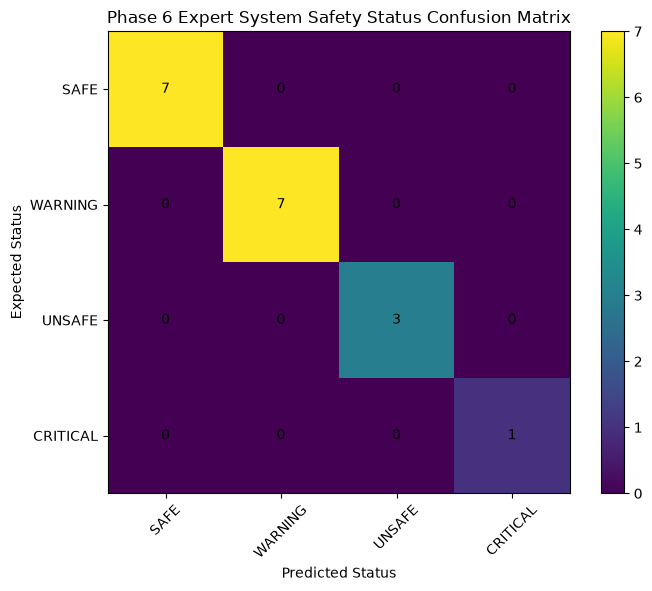

Confusion matrix saved at: E:\AI Project\AgriMind_Project\screenshots\phase6_expert_system_chemical_safety\phase6_confusion_matrix.png


In [15]:
# ============================================================
# Block 14: Confusion matrix visualization
# ============================================================

cm = confusion_matrix(y_true, y_pred, labels=status_labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Phase 6 Expert System Safety Status Confusion Matrix")
plt.xlabel("Predicted Status")
plt.ylabel("Expected Status")
plt.colorbar()

tick_marks = np.arange(len(status_labels))
plt.xticks(tick_marks, status_labels, rotation=45)
plt.yticks(tick_marks, status_labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

confusion_matrix_path = os.path.join(
    SCREENSHOTS_DIR,
    "phase6_confusion_matrix.png"
)

plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved at:", confusion_matrix_path)

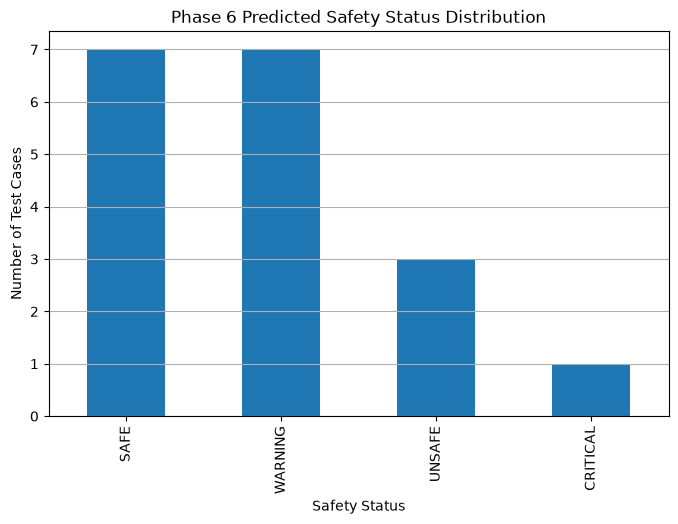

Safety status distribution graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase6_expert_system_chemical_safety\phase6_safety_status_distribution.png


predicted_status
SAFE        7
WARNING     7
UNSAFE      3
CRITICAL    1
Name: count, dtype: int64

In [16]:
# ============================================================
# Block 15: Safety status distribution graph
# ============================================================

status_distribution = results_df["predicted_status"].value_counts().reindex(status_labels, fill_value=0)

plt.figure(figsize=(8, 5))
status_distribution.plot(kind="bar")
plt.title("Phase 6 Predicted Safety Status Distribution")
plt.xlabel("Safety Status")
plt.ylabel("Number of Test Cases")
plt.grid(axis="y")

status_distribution_path = os.path.join(
    SCREENSHOTS_DIR,
    "phase6_safety_status_distribution.png"
)

plt.savefig(status_distribution_path, dpi=300, bbox_inches="tight")
plt.show()

print("Safety status distribution graph saved at:", status_distribution_path)
display(status_distribution)

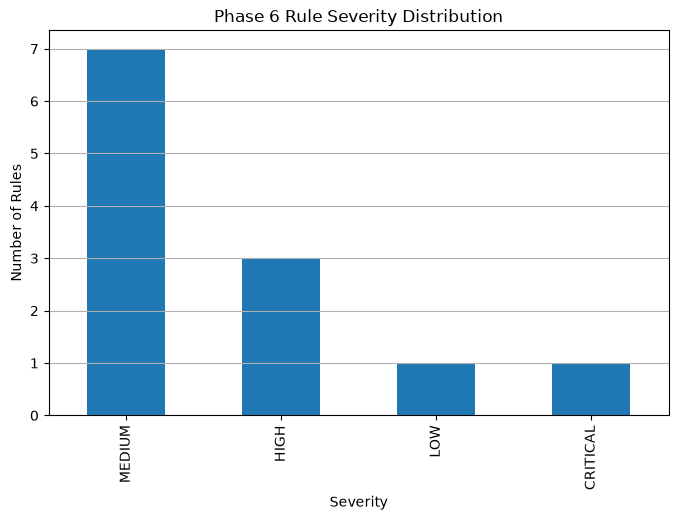

Rule severity distribution graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase6_expert_system_chemical_safety\phase6_rule_severity_distribution.png


severity
MEDIUM      7
HIGH        3
LOW         1
CRITICAL    1
Name: count, dtype: int64

In [17]:
# ============================================================
# Block 16: Rule severity distribution graph
# ============================================================

severity_distribution = rule_base_df["severity"].value_counts()

plt.figure(figsize=(8, 5))
severity_distribution.plot(kind="bar")
plt.title("Phase 6 Rule Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Rules")
plt.grid(axis="y")

severity_distribution_path = os.path.join(
    SCREENSHOTS_DIR,
    "phase6_rule_severity_distribution.png"
)

plt.savefig(severity_distribution_path, dpi=300, bbox_inches="tight")
plt.show()

print("Rule severity distribution graph saved at:", severity_distribution_path)
display(severity_distribution)

In [18]:
# ============================================================
# Block 17: Rule coverage analysis
# ============================================================

used_rule_ids = []

for rules in results_df["violated_rules"]:
    if rules != "None":
        for rule_id in rules.split(","):
            used_rule_ids.append(rule_id.strip())

used_rule_counts = pd.Series(used_rule_ids).value_counts()

rule_coverage_df = rule_base_df[["rule_id", "rule_type", "status", "severity"]].copy()
rule_coverage_df["used_count"] = rule_coverage_df["rule_id"].map(used_rule_counts).fillna(0).astype(int)
rule_coverage_df["covered_in_test_cases"] = rule_coverage_df["used_count"] > 0

display(rule_coverage_df)

coverage_rate = rule_coverage_df["covered_in_test_cases"].mean()

print("Rule coverage rate:", coverage_rate)

,rule_id,rule_type,status,severity,used_count,covered_in_test_cases
0,R001,chemical_incompatibility,UNSAFE,HIGH,1,True
1,R002,chemical_incompatibility,UNSAFE,HIGH,1,True
2,R003,chemical_incompatibility,WARNING,MEDIUM,1,True
3,R004,chemical_incompatibility,WARNING,MEDIUM,1,True
4,R005,over_application,WARNING,MEDIUM,2,True
5,R006,over_application,WARNING,MEDIUM,1,True
6,R007,soil_ph_rule,UNSAFE,HIGH,1,True
7,R008,soil_ph_rule,WARNING,MEDIUM,1,True
8,R009,growth_stage_rule,WARNING,MEDIUM,1,True
9,R010,growth_stage_rule,SAFE,LOW,0,False


Rule coverage rate: 0.9166666666666666


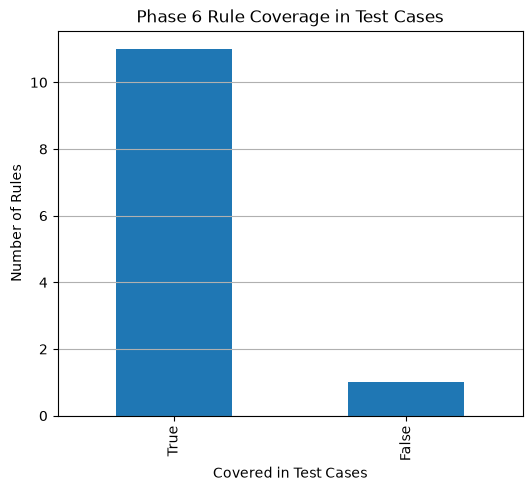

Rule coverage graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase6_expert_system_chemical_safety\phase6_rule_coverage.png


In [19]:
# ============================================================
# Block 18: Rule coverage visualization
# ============================================================

coverage_distribution = rule_coverage_df["covered_in_test_cases"].value_counts()

plt.figure(figsize=(6, 5))
coverage_distribution.plot(kind="bar")
plt.title("Phase 6 Rule Coverage in Test Cases")
plt.xlabel("Covered in Test Cases")
plt.ylabel("Number of Rules")
plt.grid(axis="y")

rule_coverage_path = os.path.join(
    SCREENSHOTS_DIR,
    "phase6_rule_coverage.png"
)

plt.savefig(rule_coverage_path, dpi=300, bbox_inches="tight")
plt.show()

print("Rule coverage graph saved at:", rule_coverage_path)

In [20]:
# ============================================================
# Block 19: Final demo function for integration with other phases
# ============================================================

def check_ai_recommendation_safety(
    crop,
    chemical_1,
    chemical_2="",
    application_action="apply_single",
    amount_level="normal",
    soil_ph=6.5,
    growth_stage="middle"
):
    case = {
        "crop": crop,
        "chemical_1": chemical_1,
        "chemical_2": chemical_2,
        "application_action": application_action,
        "amount_level": amount_level,
        "soil_ph": soil_ph,
        "growth_stage": growth_stage
    }

    result = expert_system_check(case)

    final_output = {
        "crop": crop,
        "chemical_1": chemical_1,
        "chemical_2": chemical_2,
        "application_action": application_action,
        "amount_level": amount_level,
        "soil_ph": soil_ph,
        "growth_stage": growth_stage,
        "safety_status": result["predicted_status"],
        "violated_rules": result["violated_rules"],
        "reason": result["reason"],
        "recommendation": result["recommendation"]
    }

    return final_output

demo_1 = check_ai_recommendation_safety(
    crop="Tomato",
    chemical_1="Urea",
    chemical_2="Lime",
    application_action="apply_together",
    amount_level="normal",
    soil_ph=7.2,
    growth_stage="middle"
)

demo_2 = check_ai_recommendation_safety(
    crop="Tomato",
    chemical_1="20:20:20 NPK",
    chemical_2="",
    application_action="apply_single",
    amount_level="normal",
    soil_ph=6.5,
    growth_stage="middle"
)

print("Unsafe demo:")
print(json.dumps(demo_1, indent=4))

print("\nSafe demo:")
print(json.dumps(demo_2, indent=4))

Unsafe demo:
{
    "crop": "Tomato",
    "chemical_1": "Urea",
    "chemical_2": "Lime",
    "application_action": "apply_together",
    "amount_level": "normal",
    "soil_ph": 7.2,
    "growth_stage": "middle",
    "safety_status": "UNSAFE",
    "violated_rules": "R001",
    "reason": "Urea and lime should not be mixed or applied together because ammonia volatilization can increase nitrogen loss.",
    "recommendation": "Apply urea and lime separately with a safe time gap."
}

Safe demo:
{
    "crop": "Tomato",
    "chemical_1": "20:20:20 NPK",
    "chemical_2": "",
    "application_action": "apply_single",
    "amount_level": "normal",
    "soil_ph": 6.5,
    "growth_stage": "middle",
    "safety_status": "SAFE",
    "violated_rules": "None",
    "reason": "No unsafe rule was triggered for this recommendation.",
    "recommendation": "Apply according to recommended dosage and local agricultural guidance."
}


In [21]:
# ============================================================
# Block 20: Save rule base, test cases, and results
# ============================================================

rule_base_json_path = os.path.join(MODEL_DIR, "phase6_rule_base.json")
with open(rule_base_json_path, "w") as f:
    json.dump(rule_base, f, indent=4)

rule_base_csv_path = os.path.join(RESULTS_DIR, "phase6_rule_base.csv")
rule_base_df.to_csv(rule_base_csv_path, index=False)

test_cases_path = os.path.join(RESULTS_DIR, "phase6_test_cases.csv")
test_cases_df.to_csv(test_cases_path, index=False)

test_results_path = os.path.join(RESULTS_DIR, "phase6_test_case_results.csv")
results_df.to_csv(test_results_path, index=False)

metrics_path = os.path.join(RESULTS_DIR, "phase6_evaluation_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)

rule_coverage_path_csv = os.path.join(RESULTS_DIR, "phase6_rule_coverage.csv")
rule_coverage_df.to_csv(rule_coverage_path_csv, index=False)

print("Rule base JSON saved at:", rule_base_json_path)
print("Rule base CSV saved at:", rule_base_csv_path)
print("Test cases saved at:", test_cases_path)
print("Test results saved at:", test_results_path)
print("Evaluation metrics saved at:", metrics_path)
print("Rule coverage saved at:", rule_coverage_path_csv)

Rule base JSON saved at: E:\AI Project\AgriMind_Project\models\phase6_expert_system_chemical_safety\phase6_rule_base.json
Rule base CSV saved at: E:\AI Project\AgriMind_Project\results\phase6_expert_system_chemical_safety\phase6_rule_base.csv
Test cases saved at: E:\AI Project\AgriMind_Project\results\phase6_expert_system_chemical_safety\phase6_test_cases.csv
Test results saved at: E:\AI Project\AgriMind_Project\results\phase6_expert_system_chemical_safety\phase6_test_case_results.csv
Evaluation metrics saved at: E:\AI Project\AgriMind_Project\results\phase6_expert_system_chemical_safety\phase6_evaluation_metrics.csv
Rule coverage saved at: E:\AI Project\AgriMind_Project\results\phase6_expert_system_chemical_safety\phase6_rule_coverage.csv


In [22]:
# ============================================================
# Block 21: Save Expert System configuration
# ============================================================

expert_system_config = {
    "phase": "Phase 6",
    "module": "Expert System Chemical Safety Checker",
    "ai_type": "Symbolic AI / Rule-Based AI",
    "statuses": status_labels,
    "status_priority": status_priority,
    "selected_features": selected_features,
    "rule_base_path": rule_base_json_path,
    "safety_requirement": "False-safe cases should be zero.",
    "integration_role": "Safety validation layer for ANN, RL, and other AI recommendations."
}

config_path = os.path.join(MODEL_DIR, "phase6_expert_system_config.json")

with open(config_path, "w") as f:
    json.dump(expert_system_config, f, indent=4)

print("Expert System config saved at:", config_path)

Expert System config saved at: E:\AI Project\AgriMind_Project\models\phase6_expert_system_chemical_safety\phase6_expert_system_config.json


In [23]:
# ============================================================
# Block 22: Save methodology and experiment report
# ============================================================

phase6_report = {
    "phase": "Phase 6",
    "objective": "Expert System chemical safety checker",
    "ai_type": "Symbolic AI / Rule-Based AI",
    "purpose": (
        "To check whether fertilizer/chemical recommendations generated by the AI system are safe, "
        "unsafe, warning-level, or critical before giving final advice to farmers."
    ),
    "knowledge_source": {
        "type": "Expert-defined agricultural chemical safety rule base",
        "note": "This prototype encodes common fertilizer/chemical safety rules as a rule base."
    },
    "rule_base_characteristics": rule_base_characteristics,
    "test_dataset_characteristics": {
        "number_of_test_cases": int(test_cases_df.shape[0]),
        "columns": list(test_cases_df.columns),
        "expected_status_distribution": test_cases_df["expected_status"].value_counts().to_dict()
    },
    "preprocessing_steps": {
        "importing_libraries": True,
        "creating_rule_base": True,
        "creating_test_case_dataset": True,
        "handling_missing_values": "Missing text values normalized to empty strings; pH converted to numeric and filled with median.",
        "duplicate_records": f"{int(duplicate_test_cases)} duplicate test cases removed.",
        "categorical_handling": "Chemical names, actions, amount levels, and growth stages normalized to lowercase text.",
        "numeric_handling": "Soil pH converted to numeric.",
        "feature_scaling": "pH scaled using StandardScaler only for documentation/validation; rule engine uses original pH threshold values.",
        "feature_selection": feature_selection_report
    },
    "methodology": {
        "inference_engine": "Forward-chaining style rule matching using chemical pair rules, amount rules, pH rules, and growth-stage rules.",
        "status_levels": status_labels,
        "status_priority": status_priority,
        "safety_critical_requirement": "Unsafe or critical cases should not be predicted as safe."
    },
    "evaluation_metrics": {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "false_safe_cases": int(false_safe_cases.shape[0]),
        "warning_missed_cases": int(warning_missed_cases.shape[0]),
        "rule_coverage_rate": float(coverage_rate)
    },
    "experimental_results": {
        "total_test_cases": int(len(results_df)),
        "correct_predictions": int(results_df["correct"].sum()),
        "wrong_predictions": int((~results_df["correct"]).sum()),
        "safety_error_report": safety_error_report
    },
    "visualizations": {
        "confusion_matrix": confusion_matrix_path,
        "safety_status_distribution": status_distribution_path,
        "rule_severity_distribution": severity_distribution_path,
        "rule_coverage_graph": rule_coverage_path
    },
    "saved_outputs": {
        "rule_base_json": rule_base_json_path,
        "test_results_csv": test_results_path,
        "metrics_csv": metrics_path,
        "rule_coverage_csv": rule_coverage_path_csv,
        "config_json": config_path
    }
}

report_path = os.path.join(RESULTS_DIR, "phase6_methodology_experiment_report.json")

with open(report_path, "w") as f:
    json.dump(phase6_report, f, indent=4)

print("Phase 6 methodology and experiment report saved at:", report_path)

Phase 6 methodology and experiment report saved at: E:\AI Project\AgriMind_Project\results\phase6_expert_system_chemical_safety\phase6_methodology_experiment_report.json


In [24]:
# ============================================================
# Block 23: Final Phase 6 summary
# ============================================================

print("============================================================")
print("AgriMind Phase 6 Expert System Chemical Safety Checker Completed")
print("============================================================")
print("AI Type: Symbolic AI / Rule-Based AI")
print("Number of safety rules:", len(rule_base_df))
print("Number of test cases:", len(results_df))
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("False-safe cases:", int(false_safe_cases.shape[0]))
print("Rule coverage rate:", coverage_rate)
print("Model folder:", MODEL_DIR)
print("Results folder:", RESULTS_DIR)
print("Screenshots folder:", SCREENSHOTS_DIR)
print("============================================================")

if false_safe_cases.shape[0] == 0:
    print("Safety requirement achieved: No unsafe/critical case was predicted as SAFE.")
else:
    print("Safety warning: Some unsafe/critical cases were predicted as SAFE. Review rule base.")

print("Phase 6 completed successfully.")

AgriMind Phase 6 Expert System Chemical Safety Checker Completed
AI Type: Symbolic AI / Rule-Based AI
Number of safety rules: 12
Number of test cases: 18
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
False-safe cases: 0
Rule coverage rate: 0.9166666666666666
Model folder: E:\AI Project\AgriMind_Project\models\phase6_expert_system_chemical_safety
Results folder: E:\AI Project\AgriMind_Project\results\phase6_expert_system_chemical_safety
Screenshots folder: E:\AI Project\AgriMind_Project\screenshots\phase6_expert_system_chemical_safety
Safety requirement achieved: No unsafe/critical case was predicted as SAFE.
Phase 6 completed successfully.
